# Linear Regression — Predicting Turbidity from Catchment Features

Fits `eoflow.models.LinearRegression` (an OLS wrapper) to a catchment-features CSV produced
by the pipeline in `docs/PIPELINE.md` (`scripts/prepare_samples.py` → `scripts/extract_features.py`),
and does a basic accuracy analysis of how well the terrain / soil / rainfall / EO features
predict the target determinand (Turbidity by default).

---

### Contents

1. Configuration — set `DATA_PATH` and `TARGET_COLUMN` here
2. Load & inspect data
3. Train / test split
4. Fit the model
5. Holdout accuracy
6. Predicted vs. actual, and residuals
7. Leave-one-out cross-validation (robust to the small-sample regime)
8. Feature coefficients
9. Summary

---

> **Note on sample size:** the default `DATA_PATH` below points at a 5-row sample dataset
> (`catchment_features_2020_sample5.csv`), useful for exercising the notebook end-to-end but
> too small for a statistically meaningful accuracy estimate. Point `DATA_PATH` at a larger
> extract (e.g. a full-year run of `extract_features.py`) for real analysis.

## 1 — Configuration

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import LeaveOneOut, train_test_split

from eoflow.models.base import split_features_target
from eoflow.models.LinearRegression import LinearRegression

In [2]:
# ── User-editable settings ───────────────────────────────────────────────────────────────

# Path to the features CSV written by scripts/extract_features.py
DATA_PATH = Path(
    "/home/ubuntu/enforce/eoflow/outputs/catchment_features_devon_turbidity_preview.csv"
)

# Column to predict. `result` holds the measured determinand value for every row
# (its `unit` column records which determinand) — for a CSV that has already been
# filtered to Turbidity samples (as the sample5 dataset is), this *is* Turbidity.
# Point this at a different numeric column to predict something else.
TARGET_COLUMN = "result"

# Train/test split
TEST_SIZE = 0.2
RANDOM_STATE = 0

# Model hyperparameters (see eoflow.models.LinearRegression)
FIT_INTERCEPT = True
POSITIVE = False

# ──────────────────────────────────────────────────────────────────────

assert DATA_PATH.exists(), f"CSV not found: {DATA_PATH}"

ACCENT = "#3B6FE0"      # primary series (train / fitted values)
ACCENT_MUTED = "#98A6C2"  # secondary series (test / holdout)
POSITIVE_HUE = "#2E8B7A"  # positive coefficients
NEGATIVE_HUE = "#C4553D"  # negative coefficients
GRID = "#E4E7ED"

print("Data path     :", DATA_PATH)
print("Target column :", TARGET_COLUMN)

Data path     : /home/ubuntu/enforce/eoflow/outputs/catchment_features_devon_turbidity_preview.csv
Target column : result


## 2 — Load & inspect data

In [3]:
df = pd.read_csv(DATA_PATH)
print(f"Loaded {df.shape[0]} rows × {df.shape[1]} columns")
df.head()

Loaded 173 rows × 54 columns


,notation,site_name,date,result,unit,flow_acc_at_pour_point_log,catchment_area_km2,catchment_perimeter_km,catchment_compactness,elevation_mean_m,...,rainfall_max_mm_h,rainfall_total_depth_mm,rainfall_spatial_cv,interaction_bare_x_steep10,interaction_bare_x_steep15,interaction_erodible_x_bare,interaction_wet_x_steep10,interaction_rain_x_bare,interaction_spr_x_bare,interaction_slope_mean_x_inv_ndvi
0,SW-70220104,RIVER AXE AT AXE BRIDGE BELOW COLYTON & COLYFO...,2022-04-06,3.6,NEPHELOMETRIC TURBIDITY UNITS,12.235981,124.311999,81.546100,0.234918,114.887733,...,26.00000,4.913725,4.117858,0.000436,0.000077,0.000701,0.000001,0.000168,0.165021,1.906083
1,SW-70220159,RIVER AXE AT WHITFORD BRIDGE,2010-01-05,3.6,NEPHELOMETRIC TURBIDITY UNITS,8.330864,2.505195,9.379614,0.357834,63.998347,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,SW-70220159,RIVER AXE AT WHITFORD BRIDGE,2020-02-24,13.0,NEPHELOMETRIC TURBIDITY UNITS,8.330864,2.505195,9.379614,0.357834,63.998347,...,24.71875,49.644097,3.098187,0.033663,0.005747,0.003188,0.000000,0.139559,18.819210,4.265497
3,SW-70220505,RIVER COLY AT COLYFORD,2022-04-06,2.6,NEPHELOMETRIC TURBIDITY UNITS,11.804243,80.787439,63.242372,0.253827,137.621538,...,22.00000,3.938639,3.865354,0.000256,0.000067,0.000362,0.000000,0.000038,0.040556,2.260871
4,SW-70220660,UMBORNE BROOK BELOW WILMINGTON TROUT FARM WILM...,2011-05-12,9.1,NEPHELOMETRIC TURBIDITY UNITS,10.036969,13.782646,23.393507,0.316484,185.618732,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
assert TARGET_COLUMN in df.columns, f"{TARGET_COLUMN!r} not in columns: {list(df.columns)}"

if "unit" in df.columns:
    print("Determinand unit(s) present:")
    print(df["unit"].value_counts())

print(f"\n{TARGET_COLUMN} summary:")
df[TARGET_COLUMN].describe()

Determinand unit(s) present:
unit
NEPHELOMETRIC TURBIDITY UNITS    173
Name: count, dtype: int64

result summary:


count    163.000000
mean      13.321472
std       23.659782
min        1.000000
25%        2.950000
50%        5.700000
75%       13.800000
max      162.000000
Name: result, dtype: float64

In [5]:
# Split into predictors X and target y. This drops the identity columns
# (notation, site_name, date, result, unit) and keeps every other numeric column.
X, y = split_features_target(df, target_column=TARGET_COLUMN)

n_missing = X.isna().any(axis=1).sum()
n_missing_target = y.isna().sum()
print(f"Features: {X.shape[1]} columns")
print(f"Rows with at least one missing feature: {n_missing}/{len(X)}")
print(f"Rows with missing target: {n_missing_target}/{len(y)}")

# Drop rows with any missing feature or target. LinearRegression.fit() already
# does this internally, but .predict()/.score() do not - so a NaN landing in
# the holdout split (train_test_split or LOO, below) would otherwise raise
# inside scikit-learn rather than being handled gracefully.
mask = X.notna().all(axis=1) & y.notna()
if (~mask).any():
    print(f"\nDropping {(~mask).sum()}/{len(X)} rows with missing feature(s) or target before splitting.")
X, y = X.loc[mask].reset_index(drop=True), y.loc[mask].reset_index(drop=True)
print(f"Remaining rows: {len(X)}")

Features: 49 columns
Rows with at least one missing feature: 117/173
Rows with missing target: 10/173

Dropping 120/173 rows with missing feature(s) or target before splitting.
Remaining rows: 53


## 3 — Train / test split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
print(f"Train: {len(X_train)} rows   Test: {len(X_test)} rows")

if len(X_test) < 3:
    print(
        "\nWarning: very few holdout rows — the train/test split metrics below will be "
        "noisy. See section 7 for a leave-one-out estimate that uses every row."
    )

Train: 42 rows   Test: 11 rows


## 4 — Fit the model

In [7]:
model = LinearRegression(fit_intercept=FIT_INTERCEPT, positive=POSITIVE)
model.fit(X_train, y_train)

print(f"Fitted on {len(X_train)} rows × {len(model.feature_names_)} features")
print(f"Intercept: {model.intercept:.4f}")

2026-07-23 10:42:39,426 - eoflow.models.LinearRegression - INFO - Fit LinearRegression on 42 rows × 49 features.


Fitted on 42 rows × 49 features
Intercept: -130.8101


## 5 — Holdout accuracy

In [8]:
train_metrics = model.score(X_train, y_train)
test_metrics = model.score(X_test, y_test)

metrics_df = pd.DataFrame([train_metrics, test_metrics], index=["train", "test"])
metrics_df

,r2,rmse,mae
train,0.999987,0.065281,0.015318
test,-6.925055,43.193273,32.666476


## 6 — Predicted vs. actual, and residuals

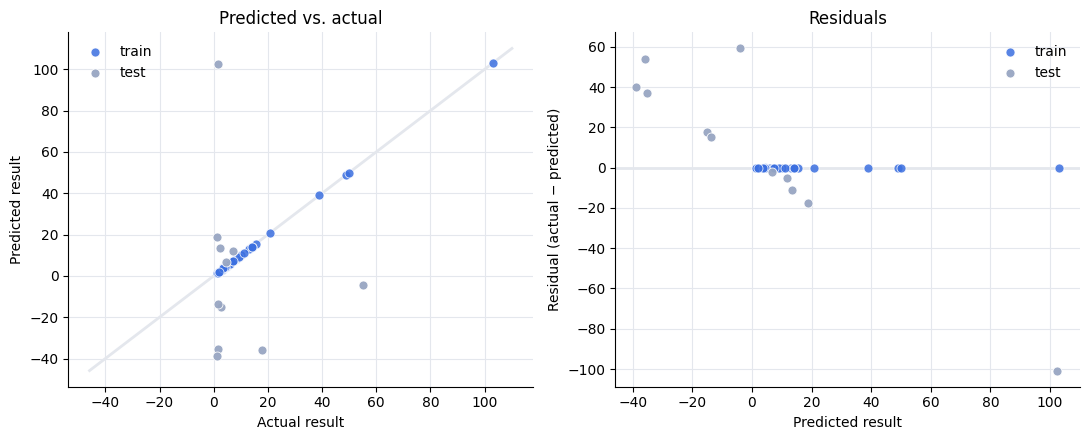

In [9]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# — Predicted vs. actual —
ax = axes[0]
all_vals = np.concatenate([y_train, y_test, y_train_pred, y_test_pred])
lo, hi = float(np.min(all_vals)), float(np.max(all_vals))
pad = 0.05 * (hi - lo if hi > lo else 1.0)
ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], color=GRID, lw=2, zorder=1, label="_nolegend_")
ax.scatter(y_train, y_train_pred, s=42, color=ACCENT, alpha=0.85, edgecolor="white", linewidth=0.6, label="train", zorder=2)
ax.scatter(y_test, y_test_pred, s=42, color=ACCENT_MUTED, alpha=0.95, edgecolor="white", linewidth=0.6, label="test", zorder=3)
ax.set_xlabel(f"Actual {TARGET_COLUMN}")
ax.set_ylabel(f"Predicted {TARGET_COLUMN}")
ax.set_title("Predicted vs. actual")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(True, color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
ax.legend(frameon=False)

# — Residuals —
ax = axes[1]
resid_train = np.asarray(y_train) - y_train_pred
resid_test = np.asarray(y_test) - y_test_pred
ax.axhline(0, color=GRID, lw=2, zorder=1)
ax.scatter(y_train_pred, resid_train, s=42, color=ACCENT, alpha=0.85, edgecolor="white", linewidth=0.6, label="train", zorder=2)
ax.scatter(y_test_pred, resid_test, s=42, color=ACCENT_MUTED, alpha=0.95, edgecolor="white", linewidth=0.6, label="test", zorder=3)
ax.set_xlabel(f"Predicted {TARGET_COLUMN}")
ax.set_ylabel("Residual (actual − predicted)")
ax.set_title("Residuals")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(True, color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
ax.legend(frameon=False)

fig.tight_layout()
plt.show()

## 7 — Leave-one-out cross-validation

A single train/test split is unstable on small datasets — which row ends up in the
holdout set can swing the metrics a lot. Leave-one-out (LOO) refits the model once
per row, holding that row out, and pools every out-of-sample prediction into one set
of accuracy metrics. It's more expensive but uses every row as a test point exactly
once, giving a steadier estimate — especially useful while the sample dataset is
this small.

In [10]:
loo = LeaveOneOut()
y_true_loo, y_pred_loo = [], []

for train_idx, holdout_idx in loo.split(X):
    fold_model = LinearRegression(fit_intercept=FIT_INTERCEPT, positive=POSITIVE)
    fold_model.fit(X.iloc[train_idx], y.iloc[train_idx])
    y_pred_loo.append(fold_model.predict(X.iloc[holdout_idx])[0])
    y_true_loo.append(y.iloc[holdout_idx].to_numpy()[0])

y_true_loo = np.asarray(y_true_loo, dtype=float)
y_pred_loo = np.asarray(y_pred_loo, dtype=float)
resid_loo = y_true_loo - y_pred_loo

ss_res = float(np.sum(resid_loo**2))
ss_tot = float(np.sum((y_true_loo - y_true_loo.mean()) ** 2))
loo_metrics = {
    "r2": 1.0 - ss_res / ss_tot if ss_tot > 0 else float("nan"),
    "rmse": float(np.sqrt(np.mean(resid_loo**2))),
    "mae": float(np.mean(np.abs(resid_loo))),
}

metrics_df.loc["loo"] = loo_metrics
metrics_df

2026-07-23 10:42:40,491 - eoflow.models.LinearRegression - INFO - Fit LinearRegression on 52 rows × 49 features.


2026-07-23 10:42:40,501 - eoflow.models.LinearRegression - INFO - Fit LinearRegression on 52 rows × 49 features.


2026-07-23 10:42:40,510 - eoflow.models.LinearRegression - INFO - Fit LinearRegression on 52 rows × 49 features.


2026-07-23 10:42:40,516 - eoflow.models.LinearRegression - INFO - Fit LinearRegression on 52 rows × 49 features.


2026-07-23 10:42:40,522 - eoflow.models.LinearRegression - INFO - Fit LinearRegression on 52 rows × 49 features.


...

2026-07-23 10:42:40,746 - eoflow.models.LinearRegression - INFO - Fit LinearRegression on 52 rows × 49 features.


2026-07-23 10:42:40,751 - eoflow.models.LinearRegression - INFO - Fit LinearRegression on 52 rows × 49 features.


2026-07-23 10:42:40,755 - eoflow.models.LinearRegression - INFO - Fit LinearRegression on 52 rows × 49 features.


2026-07-23 10:42:40,761 - eoflow.models.LinearRegression - INFO - Fit LinearRegression on 52 rows × 49 features.


,r2,rmse,mae
train,0.999987,0.065281,0.015318
test,-6.925055,43.193273,32.666476
loo,-38.810204,111.488127,69.129111


## 8 — Feature coefficients

Coefficients from the model fitted on the full training split (section 4), largest
`TOP_N_COEFS` by magnitude. Because features are on very different scales (fractions in
`[0, 1]` vs. `catchment_area_km2` in the hundreds), a large coefficient does not
necessarily mean an important feature — treat this as a sign/direction check rather
than a feature-importance ranking.

Showing the 20 largest-magnitude coefficients of 49.


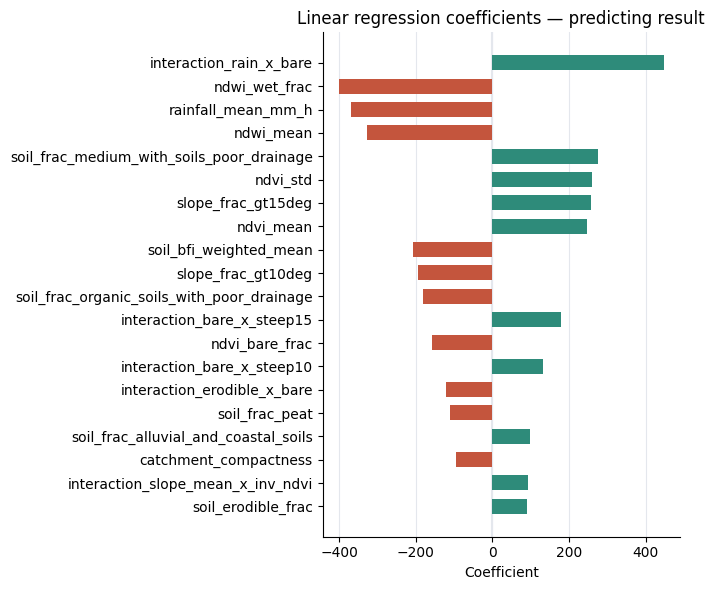

In [11]:
TOP_N_COEFS = 20

coefs = model.coefficients.reindex(model.coefficients.abs().sort_values().index)
if len(coefs) > TOP_N_COEFS:
    coefs = coefs.iloc[-TOP_N_COEFS:]
    print(f"Showing the {TOP_N_COEFS} largest-magnitude coefficients of {len(model.coefficients)}.")
colors = [POSITIVE_HUE if c >= 0 else NEGATIVE_HUE for c in coefs]

fig, ax = plt.subplots(figsize=(7, max(3, 0.3 * len(coefs))))
ax.barh(coefs.index, coefs.to_numpy(), color=colors, height=0.65)
ax.axvline(0, color=GRID, lw=1.5, zorder=0)
ax.set_xlabel("Coefficient")
ax.set_title(f"Linear regression coefficients — predicting {TARGET_COLUMN}")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(True, axis="x", color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()

## 9 — Summary

In [12]:
print(f"Dataset      : {DATA_PATH.name}  ({len(df)} rows)")
print(f"Target       : {TARGET_COLUMN}")
print(f"Features     : {len(model.feature_names_)}")
print()
print("Accuracy (R² / RMSE / MAE):")
print(metrics_df.round(4).to_string())
print()
print(
    "Note: with a handful of rows these metrics are illustrative only — re-run against "
    "a larger extract_features.py output for a meaningful accuracy read."
)

Dataset      : catchment_features_devon_turbidity_preview.csv  (173 rows)
Target       : result
Features     : 49

Accuracy (R² / RMSE / MAE):
            r2      rmse      mae
train   1.0000    0.0653   0.0153
test   -6.9251   43.1933  32.6665
loo   -38.8102  111.4881  69.1291

Note: with a handful of rows these metrics are illustrative only — re-run against a larger extract_features.py output for a meaningful accuracy read.


## 10 — What the largest coefficients mean

Reference table for the 20 largest-magnitude coefficients plotted in section 8 (this run's
53-row usable subset of the 173-sample preview). All features are computed in
`eoflow/features.py` from the layers `prepare_samples.py` saves per sample. Sign is the
direction of the fitted relationship with turbidity *in this specific fit* — with 49 features
over ~42 training rows the model is badly overfit (see section 5), so treat these as
illustrative of what each feature represents, not as reliable effect directions or an
importance ranking (features are on very different scales, so coefficient magnitude isn't
comparable across rows either).

| Feature | Coefficient | Meaning | How it's calculated |
|---|---:|---|---|
| `interaction_rain_x_bare` | +447.1 | Rainfall intensity × bare-ground fraction — rain falling on exposed soil, a classic erosion/turbidity driver | `rainfall_mean_mm_h × ndvi_bare_frac` |
| `ndwi_wet_frac` | −401.0 | Fraction of the catchment classed as open water / saturated ground | Fraction of catchment NDWI pixels (time-averaged) with NDWI > 0.0, from Sentinel-2 |
| `rainfall_mean_mm_h` | −369.9 | Mean rainfall intensity over the sample's rainfall window | Mean of all finite NIMROD radar pixel values (mm/h) over the window (`--rainfall-days` before the sample date) |
| `ndwi_mean` | −327.2 | Mean surface-moisture index across the catchment | Mean NDWI over catchment pixels, time-averaged over the EO window |
| `soil_frac_medium_with_soils_poor_drainage` | +274.7 | Fractional catchment coverage of the SEARG "medium soils with poor drainage" group | Area fraction from the SEARG soil-type API query, clipped to the catchment polygon |
| `ndvi_std` | +260.9 | Spatial variability of vegetation greenness within the catchment | Std. dev. of time-averaged NDVI across catchment pixels |
| `slope_frac_gt15deg` | +258.2 | Fraction of the catchment steeper than 15° | Fraction of DEM slope pixels exceeding the 15° threshold |
| `ndvi_mean` | +248.1 | Mean vegetation greenness across the catchment | Mean of time-averaged NDVI over catchment pixels (Sentinel-2 B08/B04) |
| `soil_bfi_weighted_mean` | −207.2 | Area-weighted Base Flow Index — how much rainfall becomes slow subsurface flow vs. fast runoff (higher = less flashy) | SEARG polygon `BFI` values, weighted by each polygon's area of overlap with the catchment |
| `slope_frac_gt10deg` | −193.3 | Fraction of the catchment steeper than 10° | Fraction of DEM slope pixels exceeding the 10° threshold |
| `soil_frac_organic_soils_with_poor_drainage` | −181.5 | Fractional catchment coverage of organic, poorly-drained soils | SEARG area fraction |
| `interaction_bare_x_steep15` | +179.8 | Bare ground on steep (>15°) slopes — an erosion-prone combination | `ndvi_bare_frac × slope_frac_gt15deg` |
| `ndvi_bare_frac` | −157.2 | Fraction of the catchment classed as bare/sparse vegetation | Fraction of time-averaged NDVI pixels below 0.2 |
| `interaction_bare_x_steep10` | +131.2 | Bare ground on moderately steep (>10°) slopes | `ndvi_bare_frac × slope_frac_gt10deg` |
| `interaction_erodible_x_bare` | −122.0 | Erodible soils that are also bare | `soil_erodible_frac × ndvi_bare_frac` |
| `soil_frac_peat` | −111.0 | Fractional catchment coverage of peat soils | SEARG area fraction |
| `soil_frac_alluvial_and_coastal_soils` | +98.9 | Fractional catchment coverage of alluvial/coastal soils (one of the "erodible" groups below) | SEARG area fraction |
| `catchment_compactness` | −95.3 | Catchment shape descriptor (1.0 = circular, → 0 = elongated) | Polsby–Popper ratio `4π·Area / Perimeter²`, computed in BNG (EPSG:27700) |
| `interaction_slope_mean_x_inv_ndvi` | +92.3 | Mean slope weighted by lack of vegetation cover | `slope_mean_deg × (1 − ndvi_mean)` |
| `soil_erodible_frac` | +89.0 | Fractional coverage of structurally erodible soil groups | Sum of SEARG area fractions for: Alluvial and coastal soils, Light free drainage, Light soils with moderate & poor drainage, Shallow soils |

**Thresholds used above** (all `extract_features.py` defaults): bare NDVI < 0.20, dense NDVI > 0.60, wet NDWI > 0.00, steep slope at 10° and 15°.
